In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input


In [2]:
benign_data = pd.read_csv('l2-benign.csv')
malicious_data  = pd.read_csv('l2-malicious.csv')

benign_data['Label'] = 0
malicious_data ['Label'] = 1

combined_data = pd.concat([benign_data, malicious_data], ignore_index=True)
combined_data.head()


,SourceIP,DestinationIP,SourcePort,DestinationPort,TimeStamp,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,...,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation,Label
0,192.168.20.191,176.103.130.131,50749,443,14-01-2020 15:49,95.081550,62311,655.342703,65358,687.388878,...,0.574626,0.001053,0.032457,0.027624,0.026854,0.026822,0.071187,0.024715,1.174948,0
1,192.168.20.191,176.103.130.131,50749,443,14-01-2020 15:50,122.309318,93828,767.136973,101232,827.672018,...,0.509047,0.001170,0.034200,0.024387,0.021043,0.026981,0.293297,-0.075845,1.402382,0
2,192.168.20.191,176.103.130.131,50749,443,14-01-2020 15:52,120.958413,38784,320.639127,38236,316.108645,...,0.732636,0.000785,0.028021,0.029238,0.026922,0.026855,0.248064,0.085061,0.958348,0
3,192.168.20.191,176.103.130.131,50749,443,14-01-2020 15:54,110.501080,61993,561.017141,69757,631.278898,...,0.646859,0.000411,0.020274,0.019925,0.019268,0.026918,0.097199,-0.344926,1.017535,0
4,176.103.130.131,192.168.20.191,443,50749,14-01-2020 15:56,54.229891,83641,1542.341289,76804,1416.266907,...,0.507334,0.079079,0.281209,0.025930,0.000046,0.000021,0.276133,0.092135,10.844829,0


In [3]:
irrelevant_columns = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
combined_data = combined_data.drop(columns=[col for col in irrelevant_columns if col in combined_data.columns], errors='ignore')
cleaned_data = combined_data.dropna()

features = cleaned_data.drop(columns=['Label']).select_dtypes(include=[np.number])
target = cleaned_data['Label']

feature_scaler = StandardScaler()
features_scaled = feature_scaler.fit_transform(features)

# Prepare 3 dimensional data for LSTM deep learning model
features_lstm = features_scaled.reshape((features_scaled.shape[0], 1, features_scaled.shape[1]))

# Data Split
features_ml_train, features_ml_test, target_ml_train, target_ml_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)
features_lstm_train, features_lstm_test, target_lstm_train, target_lstm_test = train_test_split(features_lstm, target, test_size=0.2, random_state=42)


In [4]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

ml_results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(features_ml_train, target_ml_train)
    predictions  = model.predict(features_ml_test)
    probabilities  = model.predict_proba(features_ml_test)[:, 1]

    report = classification_report(target_ml_test, predictions, output_dict=True)
    roc_score = roc_auc_score(target_ml_test, probabilities)

    ml_results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (Malicious)": report["1"]["precision"],
        "Recall (Malicious)": report["1"]["recall"],
        "F1-Score (Malicious)": report["1"]["f1-score"],
        "ROC AUC": roc_score
    })

combined_ml_results = pd.DataFrame(ml_results)
print("\nTraditional ML Results:\n", combined_ml_results)


Training Random Forest...
Training Gradient Boosting...
Training Support Vector Machine...
Training Logistic Regression...

Traditional ML Results:
                     Model  Accuracy  Precision (Malicious)  \
0           Random Forest  0.999870               0.999900   
1       Gradient Boosting  0.999889               0.999920   
2  Support Vector Machine  0.995228               0.996326   
3     Logistic Regression  0.975566               0.981209   

   Recall (Malicious)  F1-Score (Malicious)   ROC AUC  
0            0.999960              0.999930  1.000000  
1            0.999960              0.999940  1.000000  
2            0.998539              0.997431  0.998547  
3            0.992676              0.986909  0.960637  


In [5]:
traffic_classifier_model = Sequential([
    Input(shape=(features_lstm_train.shape[1], features_lstm_train.shape[2])),
    LSTM(units=64, return_sequences=False),
    Dropout(rate=0.5),
    Dense(units=1, activation='sigmoid')
])

traffic_classifier_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

training_history = traffic_classifier_model.fit(
    features_lstm_train,
    target_lstm_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9605 - loss: 0.1289 - val_accuracy: 0.9884 - val_loss: 0.0357
Epoch 2/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9894 - loss: 0.0332 - val_accuracy: 0.9927 - val_loss: 0.0221
Epoch 3/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9927 - loss: 0.0228 - val_accuracy: 0.9947 - val_loss: 0.0159
Epoch 4/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9944 - loss: 0.0176 - val_accuracy: 0.9962 - val_loss: 0.0117
Epoch 5/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9955 - loss: 0.0139 - val_accuracy: 0.9975 - val_loss: 0.0087
Epoch 6/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9977 - val_loss: 0.0076
Epoch 7/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9968 - loss: 0.0101 - val_accuracy: 0.9980 - val_loss: 0.0068
Epoch 8/10
5386/5386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9972 - loss: 0.0085 -

In [6]:
lstm_prediction_probabilities = traffic_classifier_model.predict(features_lstm_test)
lstm_predictions = (lstm_prediction_probabilities > 0.5).astype("int32")

lstm_performance_report = classification_report(target_lstm_test, lstm_predictions, output_dict=True)
lstm_roc_auc = roc_auc_score(target_lstm_test, lstm_predictions)

lstm_results = {
    "Model": "LSTM",
    "Accuracy": lstm_performance_report["accuracy"],
    "Precision (Malicious)": lstm_performance_report["1"]["precision"],
    "Recall (Malicious)": lstm_performance_report["1"]["recall"],
    "F1-Score (Malicious)": lstm_performance_report["1"]["f1-score"],
    "ROC AUC": lstm_roc_auc
}

combined_lstm_results = pd.DataFrame([lstm_results])
print("\nDeep Learning (LSTM) Results:\n", combined_lstm_results)


1684/1684 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step

Deep Learning (LSTM) Results:
   Model  Accuracy  Precision (Malicious)  Recall (Malicious)  \
0  LSTM  0.998515                0.99922             0.99918   

   F1-Score (Malicious)   ROC AUC  
0                0.9992  0.994576  


In [7]:
combined_results = pd.concat([combined_ml_results, combined_lstm_results], ignore_index=True)
print("\nCombined ML and DL Results:\n", combined_results)



Combined ML and DL Results:
                     Model  Accuracy  Precision (Malicious)  \
0           Random Forest  0.999870               0.999900   
1       Gradient Boosting  0.999889               0.999920   
2  Support Vector Machine  0.995228               0.996326   
3     Logistic Regression  0.975566               0.981209   
4                    LSTM  0.998515               0.999220   

   Recall (Malicious)  F1-Score (Malicious)   ROC AUC  
0            0.999960              0.999930  1.000000  
1            0.999960              0.999940  1.000000  
2            0.998539              0.997431  0.998547  
3            0.992676              0.986909  0.960637  
4            0.999180              0.999200  0.994576  


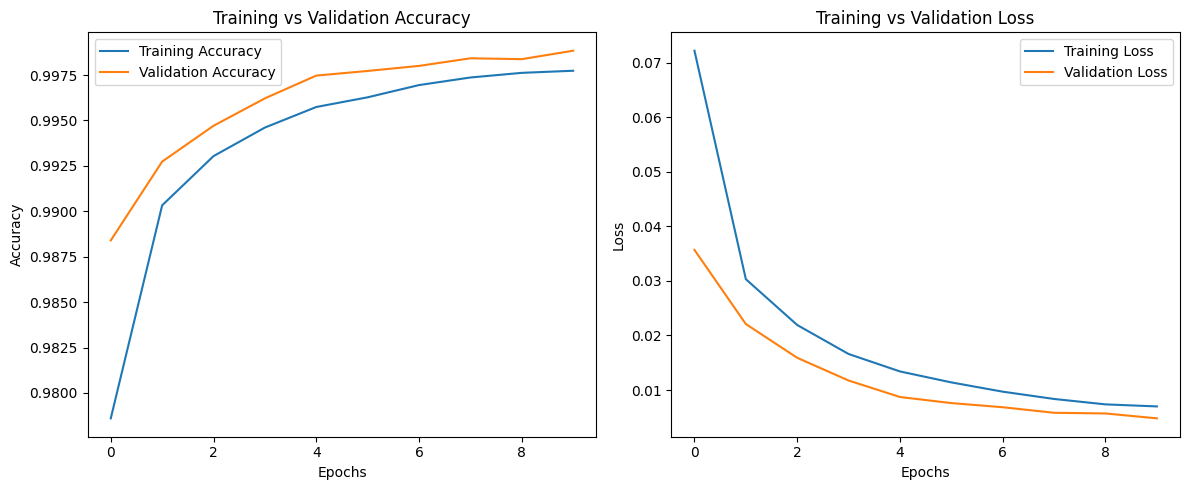

In [8]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


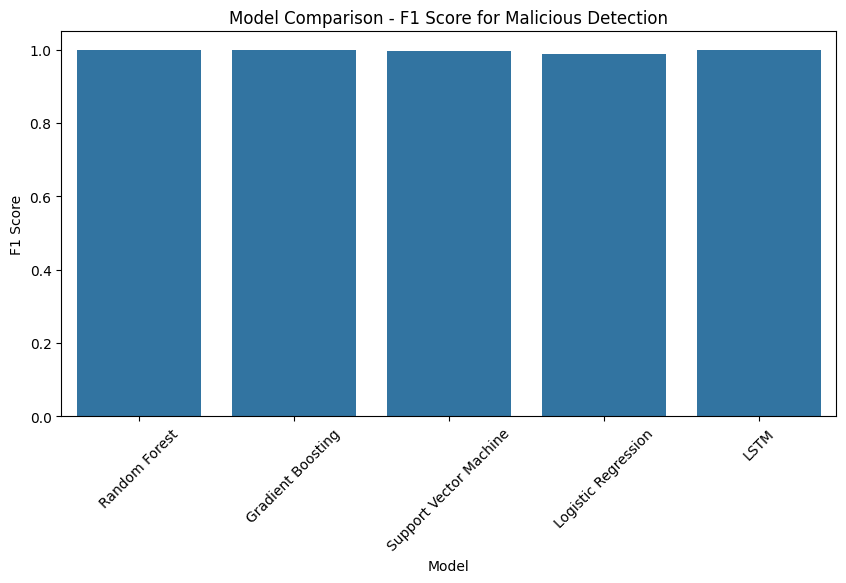

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='F1-Score (Malicious)', data=combined_results)
plt.title('Model Comparison - F1 Score for Malicious Detection')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.show()
